# Jacobian unit-test figures — Test Case G (rotation invariance)

Figures for **Test Case G** of `tests/test_jacobian.py`
(`test_jacobian_real_grid_rotation_invariance_trace_curl`).

**Idea.** The **trace** (divergence `du_λ/dλ + dv_φ/dφ`) and the
**antisymmetric part** (vorticity `dv_φ/dλ − du_λ/dφ`) of the
velocity-gradient tensor are invariant under an orthogonal rotation
of the frame. So on the real LLC4320 grid the *geographic*-frame
divergence/vorticity (real `CS`/`SN`) must match the *model*-frame
ones (identity rotation) computed from the **same real surface
U, V** — a strong, truth-free check of the rotation logic.

It is not bit-exact everywhere: differencing the *rotated* field
injects tiny `grad(CS)` terms near grid singularities, so the test
asserts robust statistics (median≈0, RMS diff < 2% of signal,
99th-pct tiny) while confirming the signal itself is large.

*Network note:* reuses the local caches `tj.REAL_GRID_CACHE` and
`tj.REAL_UV_CACHE` if present, else downloads (grid from S3, U/V
from the OSN surface kerchunk).

Generated by JXP and Claude

In [1]:
# Imports at top (project convention). We reuse tests/test_jacobian.py so
# the figures are built from the same loaders, helper and assertion the
# unit test uses.
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import dbof.utils.native_gradient as ng

_REPO = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
_TESTS = os.path.join(_REPO, 'tests')
if _TESTS not in sys.path:
    sys.path.insert(0, _TESTS)

import test_jacobian as tj  # noqa: E402

print('grid cache:', tj.REAL_GRID_CACHE)
print('U,V  cache:', tj.REAL_UV_CACHE, '| date', tj.REAL_UV_DATE)


grid cache: /tmp/llc4320_grid_cache.nc
U,V  cache: /tmp/llc4320_caseG_UV.nc | date 2012-11-09 12:00:00


## 1. Load grid + real surface velocities; run both Jacobians

We reuse `tj.load_real_llc_grid`, `tj.load_real_llc_surface_velocity`
and `tj.model_frame_jacobian` — the exact code the test runs. The
model frame is just `calculate_jacobian` with `CS=1, SN=0`.

In [2]:
ds = tj.load_real_llc_grid()
grid = tj.set_xgcm_grid(ds.drop_vars('hFacC'), use_connections=True)
u_x, v_y = tj.load_real_llc_surface_velocity()
u_x = u_x.assign_coords({c: ds.coords[c] for c in u_x.dims if c in ds.coords})
v_y = v_y.assign_coords({c: ds.coords[c] for c in v_y.dims if c in ds.coords})

geo = ng.calculate_jacobian(u_x, v_y, ds, grid)     # geographic (real CS/SN)
mod = tj.model_frame_jacobian(u_x, v_y, ds, grid)   # model frame (identity)

geo_div, mod_div = geo[0] + geo[3], mod[0] + mod[3]
geo_vort, mod_vort = geo[2] - geo[1], mod[2] - mod[1]

ocean = tj.interior(ds['hFacC']).values > 0
def pooled(inv):
    return tj.interior(inv).values[ocean]

for nm, gi, mi in [('divergence', geo_div, mod_div),
                   ('vorticity', geo_vort, mod_vort)]:
    g, m = pooled(gi), pooled(mi)
    fin = np.isfinite(g) & np.isfinite(m); g, m = g[fin], m[fin]
    d = np.abs(g - m)
    srms = np.sqrt(np.mean(m ** 2)); drms = np.sqrt(np.mean(d ** 2))
    print(f'{nm:11s} signalRMS={srms:.3e}  median|diff|={np.median(d):.2e}'
          f'  RMSdiff/signal={drms / srms:.2e}  99pct={np.percentile(d, 99):.2e}')


divergence  signalRMS=1.433e-05  median|diff|=0.00e+00  RMSdiff/signal=3.24e-03  99pct=1.86e-07


vorticity   signalRMS=2.026e-05  median|diff|=0.00e+00  RMSdiff/signal=2.19e-03  99pct=1.66e-07


## 2. Geographic vs model divergence look identical

Divergence on one face (downsampled, land-masked): the geographic
and model-frame maps are visually indistinguishable; their
difference (log scale) is near-zero except a faint signal where the
grid rotation varies.

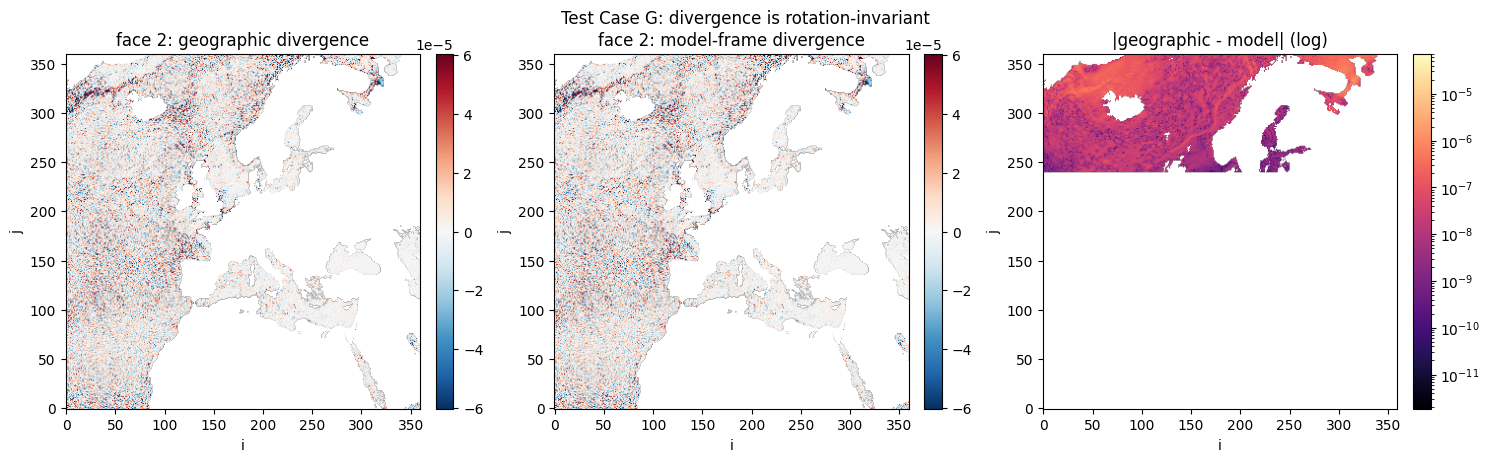

In [3]:
FACE = 2  # a face that includes some rotation variation
stride = 12
def fmap(da):
    a = da.isel(face=FACE).values[::stride, ::stride]
    lm = ds['hFacC'].isel(face=FACE).values[::stride, ::stride] > 0
    return np.where(lm, a, np.nan)

gd, md = fmap(geo_div), fmap(mod_div)
vmax = np.nanpercentile(np.abs(md), 99) or 1e-6
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, img, ttl in [(axes[0], gd, 'geographic divergence'),
                     (axes[1], md, 'model-frame divergence')]:
    pcm = ax.imshow(img, origin='lower', cmap='RdBu_r',
                    vmin=-vmax, vmax=vmax)
    fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title('face %d: %s' % (FACE, ttl))
    ax.set_xlabel('i'); ax.set_ylabel('j')
diff = np.abs(gd - md)
dpos = diff[np.isfinite(diff) & (diff > 0)]
pcm = axes[2].imshow(diff, origin='lower', cmap='magma',
                     norm=LogNorm(vmin=max(dpos.min(), 1e-20),
                                  vmax=dpos.max()) if dpos.size else None)
fig.colorbar(pcm, ax=axes[2], fraction=0.046, pad=0.04)
axes[2].set_title('|geographic - model| (log)')
axes[2].set_xlabel('i'); axes[2].set_ylabel('j')
fig.suptitle('Test Case G: divergence is rotation-invariant')
fig.tight_layout(); plt.show()


## 3. Invariance as a 1:1 relationship

Geographic vs model-frame divergence and vorticity for a random
sample of ocean-interior points fall on the `y = x` line — the
definition of invariance.

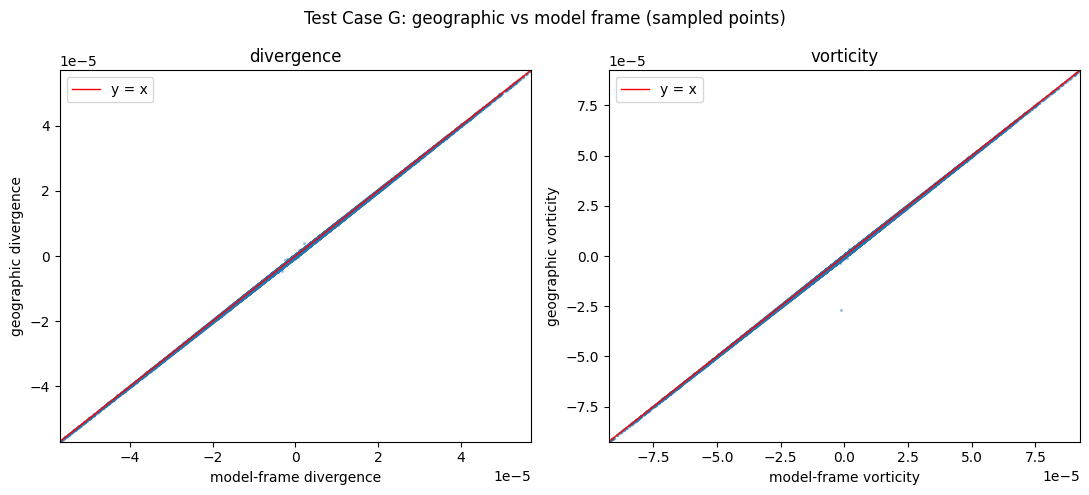

In [4]:
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, nm, gi, mi in [(axes[0], 'divergence', geo_div, mod_div),
                       (axes[1], 'vorticity', geo_vort, mod_vort)]:
    g, m = pooled(gi), pooled(mi)
    fin = np.isfinite(g) & np.isfinite(m); g, m = g[fin], m[fin]
    idx = rng.choice(g.size, size=min(40000, g.size), replace=False)
    ax.scatter(m[idx], g[idx], s=2, alpha=0.3)
    lim = np.nanpercentile(np.abs(m), 99.5)
    ax.plot([-lim, lim], [-lim, lim], 'r-', lw=1, label='y = x')
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel('model-frame %s' % nm)
    ax.set_ylabel('geographic %s' % nm)
    ax.set_title(nm); ax.legend()
fig.suptitle('Test Case G: geographic vs model frame (sampled points)')
fig.tight_layout(); plt.show()


## 4. The residual the test bounds

Histogram of `|geographic − model|` (log scale) for divergence,
with the signal RMS, the median (≈0 → off the left edge), the
99th-percentile and the RMS-difference shown. The whole
distribution sits far below the signal.

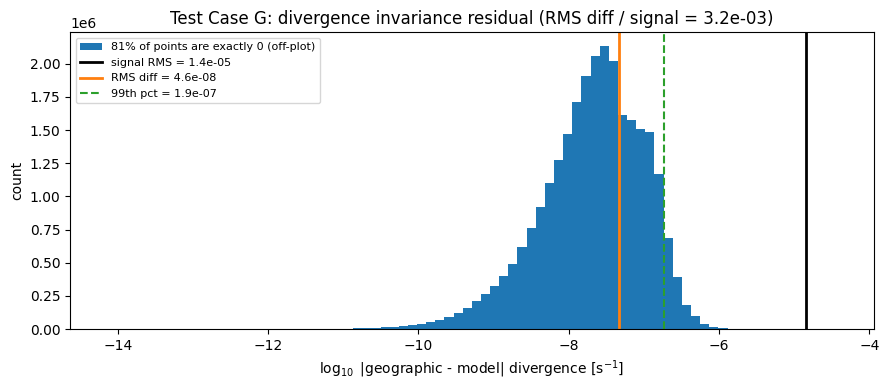

In [5]:
g, m = pooled(geo_div), pooled(mod_div)
fin = np.isfinite(g) & np.isfinite(m); g, m = g[fin], m[fin]
d = np.abs(g - m).astype('float64')
srms = np.sqrt(np.mean(m ** 2)); drms = np.sqrt(np.mean(d ** 2))
# Most points are bit-identical (diff == 0); histogram the positive tail
# in log space and report the exact-zero fraction separately.
zero_frac = np.mean(d == 0.0)
dpos = d[d > 0]
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(np.log10(dpos), bins=80,
        label=f'{zero_frac:.0%} of points are exactly 0 (off-plot)')
ax.axvline(np.log10(srms), color='k', lw=2, label=f'signal RMS = {srms:.1e}')
ax.axvline(np.log10(drms), color='C1', lw=2, label=f'RMS diff = {drms:.1e}')
ax.axvline(np.log10(np.percentile(d, 99)), color='C2', ls='--',
           label=f'99th pct = {np.percentile(d, 99):.1e}')
ax.set_xlabel(r'$\log_{10}$ |geographic - model| divergence [s$^{-1}$]')
ax.set_ylabel('count')
ax.set_title('Test Case G: divergence invariance residual '
             f'(RMS diff / signal = {drms / srms:.1e})')
ax.legend(fontsize=8); fig.tight_layout(); plt.show()


## 5. Run the actual unit test

Reuses the cached grid and velocities; no exception means Case G
passes.

In [6]:
import os
os.environ['RUN_LLC_NETWORK_TESTS'] = '1'  # opt in (caches already present)
tj.test_jacobian_real_grid_rotation_invariance_trace_curl()
print('Test Case G passed.')


Test Case G passed.
